## 
**Importing**
***

In [1]:
import sys
print(sys.executable)

c:\Users\tveit\.conda\envs\FIE463\python.exe


In [2]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt

## Part 1 - Euler equation errors
***

In [3]:
class Parameters:
    def __init__(self):
        self.beta = 0.99**30
        self.gamma = 2.1
        self.tau = 0.3
        self.phi = 0.5
        self.alpha = 0.36
        self.delta = 1 - 0.94**30
        self.z = 1.0
        self.Nw = 0.8
        self.Nk = 0.2
        self.tau_a = 0.0
        self.tau_a_iid = 0.05
        self.pi_a = 0.5

par = Parameters()

In [ ]:
def euler_err(K_next, K, par):
    """
    Compute the capitalists' Euler equation error for a given capital
    stock today and tomorrow.
    """
    # Labor supply
    L = 0.5 * par.Nw

    # Interest rates from firm FOC, at time t and t+1
    r = par.alpha * par.z * K**(par.alpha - 1) * L**(1 - par.alpha) - par.delta
    r_next = par.alpha * par.z * K_next**(par.alpha - 1) * L**(1 - par.alpha) - par.delta

    # Young capitalist's saving
    a = (2 * K_next) / par.Nk

    # Inheritance to young capitalists
    b = par.phi * (1 + r) * (2 * K) / par.Nk

    # Consumption of young and old capitalists
    c_y = b - a
    c_o = (1 - par.phi) * (1 + r_next) * a

    # Euler equation error
    LHS = c_y**(-par.gamma)
    RHS = par.beta * (1 + r_next) * (1 - par.phi) * c_o**(-par.gamma)

    return LHS - RHS

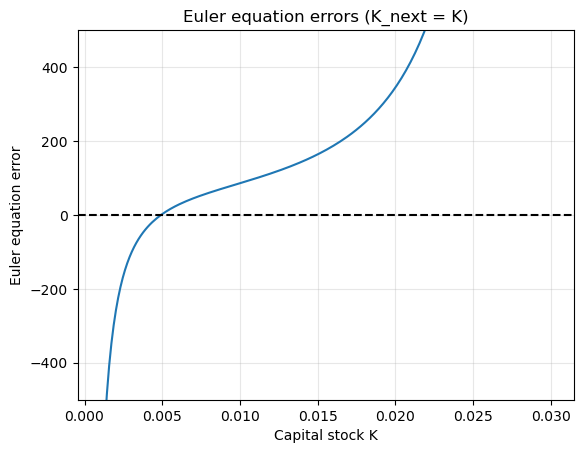

In [34]:
K_grid = np.linspace(0.001, 0.03, 200)
errors = [euler_err(K, K, par) for K in K_grid]

plt.figure()
plt.plot(K_grid, errors)
plt.grid(alpha = 0.3)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Capital stock K')
plt.ylabel('Euler equation error')
plt.title('Euler equation errors (K_next = K)')
plt.ylim(-500, 500)
plt.show()

The plot shows that the Euler equation error crosses zero around $K \approx 0.005$, confirming that the function has a root. We used 200 points in the interval \([0.001, 0.03]\) to show this.

## Part 2 - Steady state
***